In [40]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import scipy.special as sp
import pandas as pd
import torch
import seaborn as sns
import os

## 1. Open dataset and EDA

In [2]:
# Open dataset and divide test and train data

dataset = load_dataset("emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
# Example

dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [4]:
# Labels

dataset["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

So the mapping will be:

* Sadness = 0
* Joy = 1
* Love = 2
* Anger = 3
* Fear = 4
* Surprise = 5

Of course, some messages can in principle belong to different classes, even if BERT will classifying them into one.

In [5]:
# How many cases for each class (label)?

labels_list = dataset["train"]["label"]
Counter(labels_list)

Counter({1: 5362, 0: 4666, 3: 2159, 4: 1937, 2: 1304, 5: 572})

The dataset is not well balanced.

In [6]:
# Lengths of the text

lengths = [len(x.split()) for x in dataset["train"]["text"]]

print(f"Min: {min(lengths)}")
print(f"Max: {max(lengths)}")
print(f"Average: {sum(lengths)/len(lengths)}")

Min: 2
Max: 66
Average: 19.1663125


I will work of sub-datasets for computational reasons.

In [7]:
train_ds = dataset["train"].shuffle(seed=42).select(range(2000))
val_ds = dataset["validation"].shuffle(seed=42).select(range(500))
test_ds = dataset["test"].shuffle(seed=42).select(range(500))

## 2. Tokenization

In [8]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [9]:
tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [10]:
# Test the tokenizer

text = "electromagnetically"

tokens = tokenizer.tokenize(text)
tokens

['electromagnetic', '##ally']

In [11]:
# Dataset tokenization function

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [12]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

In [13]:
# check

train_ds[0]

{'text': 'while cycling in the country',
 'label': 4,
 'input_ids': [101,
  2096,
  9670,
  1999,
  1996,
  2406,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


Each token is "translated" into the index it has in the vocabulary. [CLS] token is associated to 101, [SEP] token to 102, [PAD] token to 0.

"attention_mask" tells BERT what is a token to look at and what's padding.

In [14]:
# Convert datasets into tensors

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

## 3. Model: DISTILBERT base uncased

DISTILBERT is much faster than BERT on CPU.

In [15]:
# Use pre-trained model

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=6, attn_implementation="eager")

Loading weights: 100%|█████████████████████| 100/100 [00:00<00:00, 15041.43it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
# Define metrics for evaluation

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [19]:
# Training configuration

training_args = TrainingArguments(
    output_dir="./results_emotion_bert",
    report_to="none",
    disable_tqdm=True,
    
    learning_rate = 2e-5,

    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,

    num_train_epochs = 3,
    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    greater_is_better = True,

    logging_dir = "./logs_emotion_bert",
    logging_steps = 100
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
# Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

In [21]:
# Train!

trainer.train()

/home/asus/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.076530,0.797674,0.734000,0.679075
2,0.509529,0.499344,0.826000,0.814984
3,0.291130,0.457217,0.840000,0.831510


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  2.68it/s]
/home/asus/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  2.45it/s]
/home/asus/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  5.86it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=750, training_loss=0.7011239725748698, metrics={'train_runtime': 1277.2195, 'train_samples_per_second': 4.698, 'train_steps_per_second': 0.587, 'total_flos': 198715272192000.0, 'train_loss': 0.7011239725748698, 'epoch': 3.0})

In [23]:
# History of the training

trainer.state.log_history

logs = pd.DataFrame(trainer.state.log_history)
logs

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.521648,5.343830,0.000017,0.4,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.076530,8.218097,0.000015,0.8,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.0,250,0.797674,0.734,0.679075,26.6322,18.774,2.366,NaN,NaN,NaN,NaN,NaN
3,0.791434,6.622213,0.000012,1.2,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.562741,6.001893,0.000009,1.6,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.509529,0.996905,0.000007,2.0,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,2.0,500,0.499344,0.826,0.814984,27.0461,18.487,2.329,NaN,NaN,NaN,NaN,NaN
7,0.327123,20.512636,0.000004,2.4,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.291130,11.954210,0.000001,2.8,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,3.0,750,0.457217,0.840,0.831510,26.4374,18.913,2.383,NaN,NaN,NaN,NaN,NaN


After 3 epochs, both the accuracy and the F1 score are quite high (84% and 83% respectively).

## 4. Error analysis

In [24]:
# Predictions on the test set

predictions = trainer.predict(test_ds)

logits = predictions.predictions
labels = predictions.label_ids

preds = np.argmax(logits, axis=1)

/home/asus/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [25]:
# Probabilities

probs = sp.softmax(logits, axis=1)
confidence = np.max(probs, axis=1)

In [26]:
# Mapping labels

label_names = dataset["train"].features["label"].names

In [28]:
# Errors

test_ds.set_format(type=None)

errors = []

for i in range(len(preds)):
    if preds[i] != labels[i]:
        errors.append({
            "text": test_ds[i]["text"],
            "true": label_names[labels[i]],
            "pred": label_names[preds[i]],
            "confidence": confidence[i]
        })

In [29]:
# Which are the most interesting errors?

errors = sorted(errors, key=lambda x: x["confidence"], reverse=True)

for e in errors[:10]:
    print("\nTEXT: ", e["text"])
    print("TRUE: ", e["true"])
    print("PRED: ", e["pred"])
    print("CONF: ", round(e["confidence"],3))


TEXT:  i feel underappreciated and under valued
TRUE:  joy
PRED:  sadness
CONF:  0.973

TEXT:  i actually was in a meeting last week where someone yelled at an older lady because her phone rang i felt terrible for her your boss treats you unfairly or in this case someone makes you feel you are not worth anything is only allowing those who offended to steal your joy
TRUE:  anger
PRED:  sadness
CONF:  0.969

TEXT:  i grabbed my dog and hugged her fiercly for the next hour or so until i began to feel a bit like myself again but i havent completly shaken the feeling and have been feeling rather depressed anxious all day
TRUE:  fear
PRED:  sadness
CONF:  0.968

TEXT:  i feel shame in a strange way
TRUE:  surprise
PRED:  sadness
CONF:  0.958

TEXT:  i just got back from another miler faster than yesterday and im feeling amazing
TRUE:  surprise
PRED:  joy
CONF:  0.956

TEXT:  i felt a stronger wish to be free from self cherishing through my refuge practice and a return to the feeling of free

I see that, in general, the model makes confusion with some specific combinations of true and predicted class:

* Joy and love 
* Anger and sadness 
* Fear and sadness

## 5. Attention visualization

In [35]:
# Function to visualize attention 

def visualize_attention(text, model, tokenizer, layer=0, head=0):

    # Tokenization
    inputs = tokenizer(text, return_tensors="pt")

    # Forward with attention
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions

    # Select layer and head
    attention = attentions[layer][0][head]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(attention.detach().numpy(),
               xticklabels=tokens,
               yticklabels=tokens,
               cmap="viridis")

    plt.title(f"Layer {layer} - head {head}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

In [43]:
# Upload trained model

best_path = trainer.state.best_model_checkpoint

model = AutoModelForSequenceClassification.from_pretrained(
    best_path,
    attn_implementation="eager"
)

Loading weights: 100%|█████████████████████| 104/104 [00:00<00:00, 15511.26it/s]


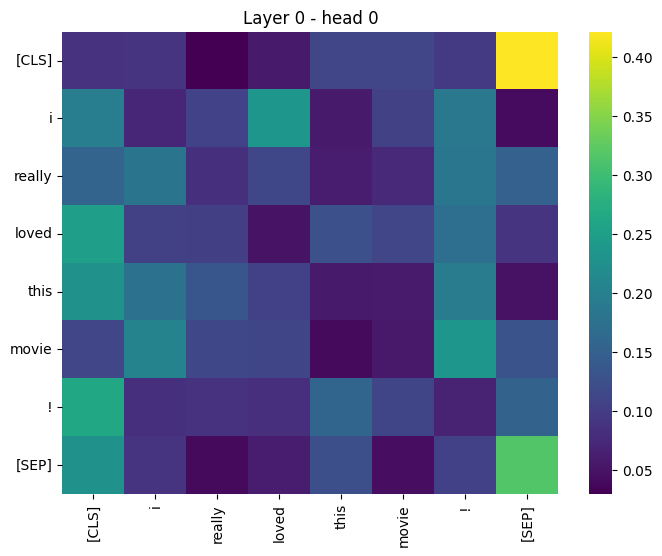

In [44]:
# Test

visualize_attention(
    "I really loved this movie!",
    model,
    tokenizer,
    layer=0,
    head=0
)

This is what a since head sees. For each word (row), it tells how much is looks at other words too (columns).

Let's consider an example of our dataset.

i just got back from another miler faster than yesterday and im feeling amazing


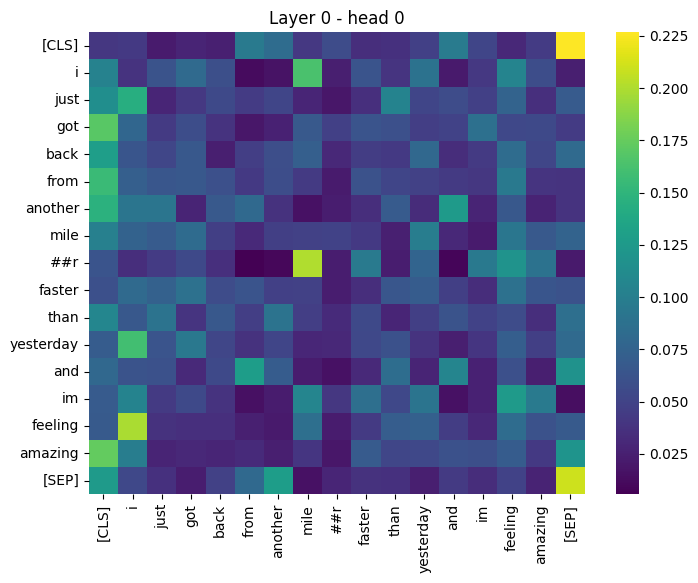

In [56]:
example = errors[4]["text"]
print(example)

visualize_attention(example, model, tokenizer)

In [61]:
# Function to visualize multiple heads

def visualize_multiple_heads(text, model, tokenizer, layer=0, num_heads=6):

    inputs = tokenizer(text, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    fig, axes = plt.subplots(1, num_heads, figsize=(25, 4))

    for i in range(num_heads):
        head = attentions[layer][0][i]

        sns.heatmap(head.detach().numpy(),
                    xticklabels=tokens,
                    yticklabels=tokens,
                    ax=axes[i],
                    cbar=False)

        axes[i].set_title(f"Head {i}")
        axes[i].tick_params(axis="x", rotation=90)

    plt.show()

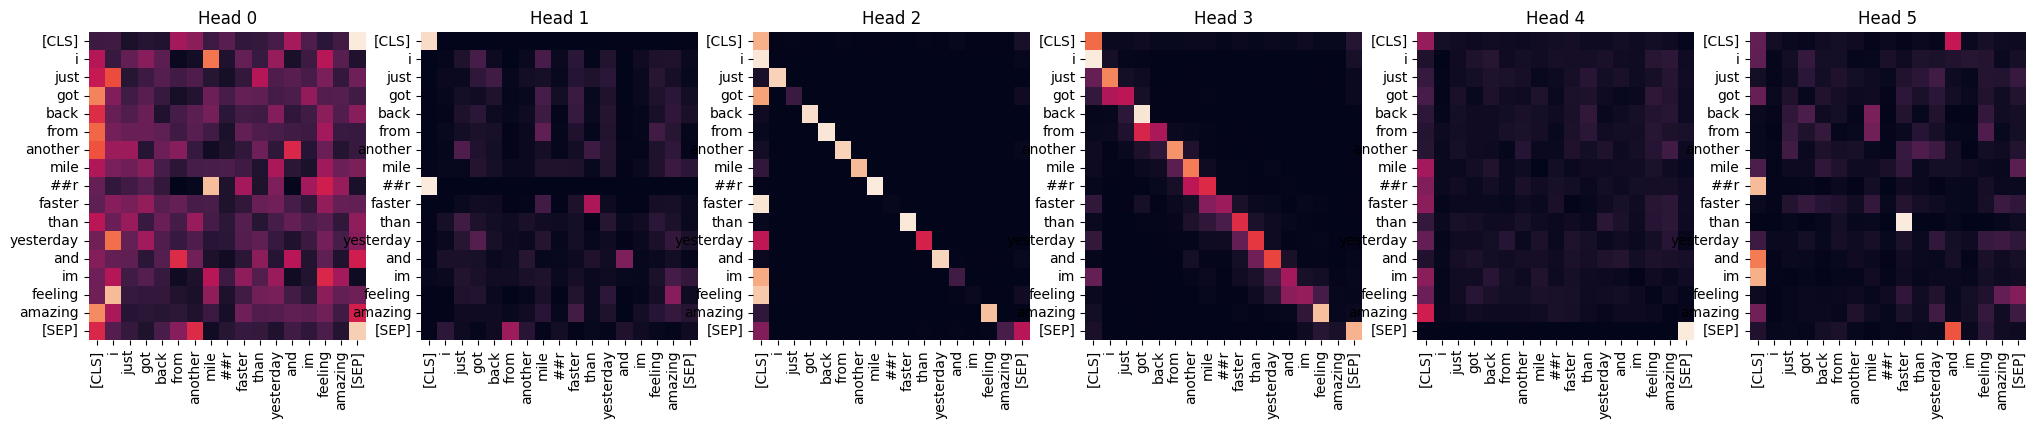

In [62]:
visualize_multiple_heads(example, model, tokenizer, layer=0)

It is clear that different heads focus on different things.

For example, heads 2 and 3 focuses on the words preceeding the current word. Heads 4 and 5 have the [CLS] column lighter; this makes sense, as this token captures the global sense of the sentence.